# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
!pip install pyarrow

In [5]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pyarrow as pa
import pyarrow.parquet as pq
import glob

try:
    import geopandas as gpd
    from shapely.geometry import Point
except Exception as e:
    print("Geo libraries not loaded yet (ok for now). We'll install when neede,")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")



Geo libraries not loaded yet (ok for now). We'll install when neede,


In [6]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.3.5
pandas version: 2.3.3
matplotlib version: 3.10.6
seaborn version: 0.13.2


In [8]:
base_path = r"C:\Users\Prakhar\Desktop\Datasets and Dictionary-NYC\Datasets and Dictionary"

### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [9]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
df = pd.read_parquet('2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?
Answer: The January 2023 dataset has about 3.6 million records, and combining all months would exceed 40 million, which is too heavy for jupyter notebook. Therefor, sampling is needed for efficient analysis while preserving trends.

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

Answer: To manage this, a sampling method can be used on each monthly file before merging them. For example, randomly selecting 5% of trips for each hour using the tpep_pickup_datetime column helps retain hourly patterns, while greatly reducing the dataset size and making the analysis more eficient.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
import pandas as pd

# Select the folder having data files
#os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')
os.chdir(r"C:\Users\Prakhar\OneDrive\Desktop\Datasets and Dictionary\trip_records")

# Create a list of all the twelve files to read
#file_list = os.listdir()
file_list = [f for f in os.listdir() if f.endswith(".parquet") and f.startswith("2023")]
file_list = sorted(
    file_list,
    key=lambda x: int(x.split("-")[1].split(".")[0])
)
print("Files found:", len(file_list))
print("First 3 files:", file_list[:3])

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)

         # Convert pickup datetime (needed for date/hour sampling)
        month_df["tpep_pickup_datetime"] = pd.to_datetime(
             month_df["tpep_pickup_datetime"], errors="coerce"
         )
         
        # Create date and hour columns
        month_df["pickup_date"] = month_df["tpep_pickup_datetime"].dt.date
        month_df["pickup_hour"] = month_df["tpep_pickup_datetime"].dt.hour



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_df["pickup_date"].dropna().unique():
            # data for a single date
            date_data = month_df[month_df["pickup_date"] == date]

            # Iterate through each hour of the selected date
            for hour, hour_data in date_data.groupby("pickup_hour"):
                if len(hour_data) > 0:
                        sample = hour_data.sample(frac=0.05, random_state=42)
                        sampled_data = pd.concat(
                            [sampled_data, sample], ignore_index=True)
                 
                # Sample 5% of the hourly data randomly
                if len(hour_data) > 0:
                    sample = hour_data.sample(frac=0.05, random_state=42)
            

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True) # we initialised this empty DF earlier

         # Free memory
        del month_df
        print(f"Done: {file_name} | sampled rows: {sampled_data.shape[0]}")


    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
print("Final combined sampled df shape:", df.shape)        

Files found: 12
First 3 files: ['2023-1.parquet', '2023-2.parquet', '2023-3.parquet']
Done: 2023-1.parquet | sampled rows: 304174
Done: 2023-2.parquet | sampled rows: 337392
Done: 2023-3.parquet | sampled rows: 327572
Done: 2023-4.parquet | sampled rows: 279282
Done: 2023-5.parquet | sampled rows: 288916
Done: 2023-6.parquet | sampled rows: 325820
Done: 2023-7.parquet | sampled rows: 348136
Done: 2023-8.parquet | sampled rows: 287564
Done: 2023-9.parquet | sampled rows: 281750
Done: 2023-10.parquet | sampled rows: 348510
Done: 2023-11.parquet | sampled rows: 330266
Done: 2023-12.parquet | sampled rows: 333418
Final combined sampled df shape: (3792800, 22)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [12]:
# Store the df in csv/parquet
# df.to_parquet('')
df = df.sample(n=300_000, random_state=42).reset_index(drop=True)

df.shape

(300000, 22)

In [13]:
# Save sampled dataset for reuse
df.to_csv("sampled_2023_taxi.csv", index=False)
print("CSV file saved successfully!")

CSV file saved successfully!


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [14]:
# Load the new data file
df = pd.read_csv("sampled_2023_taxi.csv")



In [15]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,1,2023-12-03 19:12:59,2023-12-03 19:33:13,1.0,2.80,1.0,N,100,143,1,...,0.5,3.78,0.0,1.0,24.78,2.5,NaN,2023-12-03,19,0.0
1,2,2023-02-15 18:00:40,2023-02-15 18:15:04,1.0,1.12,1.0,N,50,161,2,...,0.5,0.00,0.0,1.0,18.60,2.5,NaN,2023-02-15,18,0.0
2,2,2023-10-04 13:10:59,2023-10-04 13:18:59,1.0,1.08,1.0,N,142,48,2,...,0.5,0.00,0.0,1.0,13.30,2.5,NaN,2023-10-04,13,0.0
3,2,2023-02-12 00:24:05,2023-02-12 00:36:23,5.0,2.04,1.0,N,114,107,1,...,0.5,3.70,0.0,1.0,22.20,2.5,NaN,2023-02-12,0,0.0
4,2,2023-07-08 06:45:25,2023-07-08 07:15:57,NaN,19.33,NaN,NaN,113,132,0,...,0.5,0.00,0.0,1.0,46.12,NaN,NaN,2023-07-08,6,NaN


In [16]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               300000 non-null  int64  
 1   tpep_pickup_datetime   300000 non-null  object 
 2   tpep_dropoff_datetime  300000 non-null  object 
 3   passenger_count        289875 non-null  float64
 4   trip_distance          300000 non-null  float64
 5   RatecodeID             289875 non-null  float64
 6   store_and_fwd_flag     289875 non-null  object 
 7   PULocationID           300000 non-null  int64  
 8   DOLocationID           300000 non-null  int64  
 9   payment_type           300000 non-null  int64  
 10  fare_amount            300000 non-null  float64
 11  extra                  300000 non-null  float64
 12  mta_tax                300000 non-null  float64
 13  tip_amount             300000 non-null  float64
 14  tolls_amount           300000 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [17]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

df.drop(columns=["pickup_date", "pickup_hour"], inplace=True)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               300000 non-null  int64  
 1   tpep_pickup_datetime   300000 non-null  object 
 2   tpep_dropoff_datetime  300000 non-null  object 
 3   passenger_count        289875 non-null  float64
 4   trip_distance          300000 non-null  float64
 5   RatecodeID             289875 non-null  float64
 6   store_and_fwd_flag     289875 non-null  object 
 7   PULocationID           300000 non-null  int64  
 8   DOLocationID           300000 non-null  int64  
 9   payment_type           300000 non-null  int64  
 10  fare_amount            300000 non-null  float64
 11  extra                  300000 non-null  float64
 12  mta_tax                300000 non-null  float64
 13  tip_amount             300000 non-null  float64
 14  tolls_amount           300000 non-nu

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [18]:
# Combine the two airport fee columns
df["airport_fee"] = df[["airport_fee", "Airport_fee"]].max(axis=1)

# Drop the duplicate column
df.drop(columns=["Airport_fee"], inplace=True)



In [19]:
df[["airport_fee"]].describe()

,airport_fee
count,289875.000000
mean,0.141617
std,0.462782
min,-1.750000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.750000


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [20]:
# check where values of fare amount are negative
df[df["fare_amount"] < 0].head()

#Zero rows where fare_amount is negative.



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [21]:
# Analyse RatecodeID for the negative fare amounts
df.loc[df["fare_amount"] < 0, "RatecodeID"].value_counts(dropna=False)
#No difference was observed in the RatecodeID column 



Series([], Name: count, dtype: int64)

In [22]:
# Find which columns have negative values
# Select all numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns

# Count negative values in each numeric column
negatives_summary = {
col: (df[col] < 0).sum()
for col in numeric_cols
}

# Convert dictionary to DataFrame and sort
negatives_df = (
pd.DataFrame.from_dict(
negatives_summary,
orient="index",
columns=["negative_count"]
)
.sort_values("negative_count", ascending=False)
)

# Display result
negatives_df



,negative_count
mta_tax,13
improvement_surcharge,13
total_amount,13
congestion_surcharge,9
airport_fee,4
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0


In [23]:
# fix these negative values
monetary_cols = [
    "total_amount",
    "improvement_surcharge",
    "mta_tax",
    "congestion_surcharge",
    "airport_fee"
]
for col in monetary_cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)



In [24]:
(df[monetary_cols] < 0).sum()

total_amount             0
improvement_surcharge    0
mta_tax                  0
congestion_surcharge     0
airport_fee              0
dtype: int64

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [25]:
# Find the proportion of missing values in each column
missing_proportion = df.isnull().mean().sort_values(ascending=False)
missing_proportion



airport_fee              0.03375
congestion_surcharge     0.03375
passenger_count          0.03375
RatecodeID               0.03375
store_and_fwd_flag       0.03375
extra                    0.00000
total_amount             0.00000
improvement_surcharge    0.00000
tolls_amount             0.00000
tip_amount               0.00000
mta_tax                  0.00000
VendorID                 0.00000
fare_amount              0.00000
tpep_pickup_datetime     0.00000
DOLocationID             0.00000
PULocationID             0.00000
trip_distance            0.00000
tpep_dropoff_datetime    0.00000
payment_type             0.00000
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [26]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df["passenger_count"].isnull()].head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-07-08 06:45:25,2023-07-08 07:15:57,NaN,19.33,NaN,NaN,113,132,0,42.12,0.0,0.5,0.00,0.00,1.0,46.12,NaN,NaN
35,1,2023-12-08 23:10:25,2023-12-08 23:21:49,NaN,0.00,NaN,NaN,262,237,0,17.42,0.0,0.5,0.00,0.00,1.0,21.42,NaN,NaN
41,1,2023-10-13 18:54:09,2023-10-13 19:22:18,NaN,0.00,NaN,NaN,68,43,0,25.24,0.0,0.5,0.00,0.00,1.0,29.24,NaN,NaN
95,2,2023-05-11 19:05:35,2023-05-11 19:59:46,NaN,9.76,NaN,NaN,237,61,0,43.92,0.0,0.5,5.45,6.55,1.0,59.92,NaN,NaN
153,2,2023-10-23 19:09:19,2023-10-23 19:50:40,NaN,9.74,NaN,NaN,233,188,0,46.73,0.0,0.5,5.07,0.00,1.0,55.80,NaN,NaN


In [27]:
(df["passenger_count"] == 0).sum()

np.int64(4737)

In [28]:
# Treat passenger_count = 0 as missing
df.loc[df["passenger_count"] == 0, "passenger_count"] = np.nan
# Impute missing passenger_count using the median
median_passenger_count = df["passenger_count"].median()
df["passenger_count"].fillna(median_passenger_count, inplace=True)

Did you find zeroes in passenger_count? Handle these.
Ans-No zero values were found in the passenger_count column in the sampled dataset. To handle potential gaps, any zero passenger counts were treated as misdsing and replaced with the median value.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [29]:
# Fix missing values in 'RatecodeID'
# Check missing values in RatecodeID
df["RatecodeID"].isnull().sum()


np.int64(10125)

In [30]:
# Impute missing RatecodeID using the most frequent value (mode)
ratecode_mode = df["RatecodeID"].mode()[0]
df["RatecodeID"].fillna(ratecode_mode, inplace=True)

In [31]:
# Verify no missing values remain
df["RatecodeID"].isnull().sum()

np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [32]:
# handle null values in congestion_surcharge
df["congestion_surcharge"].isnull().sum()




np.int64(10125)

In [33]:
# Impute missing congestion_surcharge with 0
df["congestion_surcharge"].fillna(0, inplace=True)

In [34]:
# Verify no missing values remain
df["congestion_surcharge"].isnull().sum()

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [35]:
# Handle any remaining missing values
df.isnull().sum().sort_values(ascending=False)


airport_fee              10125
store_and_fwd_flag       10125
fare_amount                  0
congestion_surcharge         0
total_amount                 0
improvement_surcharge        0
tolls_amount                 0
tip_amount                   0
mta_tax                      0
extra                        0
VendorID                     0
tpep_pickup_datetime         0
DOLocationID                 0
PULocationID                 0
RatecodeID                   0
trip_distance                0
passenger_count              0
tpep_dropoff_datetime        0
payment_type                 0
dtype: int64

In [36]:
# Impute missing values in store_and_fwd_flag
df["store_and_fwd_flag"].fillna("N", inplace=True)
# Impute missing values in airport_fee
df["airport_fee"].fillna(0, inplace=True)
# Final check
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [37]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,300000.000000,300000.000000,300000.000000,300000.00000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,1.732570,1.370967,3.859565,1.61926,165.207513,164.017217,1.164330,19.796832,1.588744,0.495224,3.542838,0.593516,0.999039,28.850770,2.229042,0.136859
std,0.447413,0.864773,101.782222,7.30940,63.997122,69.772113,0.508186,18.158128,1.829567,0.048704,4.036393,2.178841,0.028618,22.707458,0.777161,0.455578
min,1.000000,1.000000,0.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.040000,1.00000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,1.000000,1.790000,1.00000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,1.000000,3.400000,1.00000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,8.000000,33133.960000,99.00000,265.000000,265.000000,4.000000,700.000000,11.750000,0.800000,194.420000,86.000000,1.000000,701.000000,2.500000,1.750000


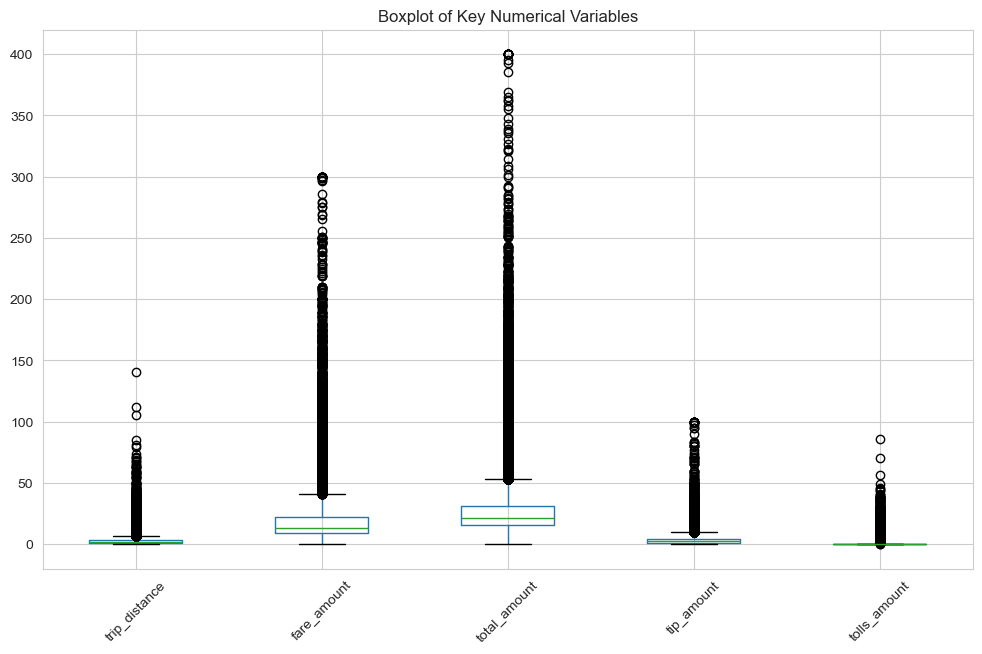

In [99]:
# Select key numerical columns for outlier inspection
numeric_cols = [
"trip_distance",
"fare_amount",
"total_amount",
"tip_amount",
"tolls_amount"
]
# Visualize boxplots to identify outliers
plt.figure(figsize=(12, 7))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Key Numerical Variables")
plt.show()
#outliers exist and boxplot shows them compressed near zero with huge spikes

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [39]:
# remove passenger_count > 6
df = df[df["passenger_count"] <= 6]

In [40]:
# Continue with outlier handling
df = df[~((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300))]

# Remove trips with zero distance and zero fare but different pickup/dropoff zones
df = df[~(
    (df["trip_distance"] == 0) &
    (df["fare_amount"] == 0) &
    (df["PULocationID"] != df["DOLocationID"])
)]
# Remove unrealistically long trips
df = df[df["trip_distance"] <= 250]

# Handle undefined payment type (0)
df.loc[df["payment_type"] == 0, "payment_type"] = np.nan
df["payment_type"].fillna(df["payment_type"].mode()[0], inplace=True)

# Cap extreme monetary values
df["fare_amount"] = df["fare_amount"].clip(upper=300)
df["total_amount"] = df["total_amount"].clip(upper=400)
df["tip_amount"] = df["tip_amount"].clip(upper=100)
df["tolls_amount"] = df["tolls_amount"].clip(upper=100)


In [41]:
# Do any columns need standardising?
# Standardise store_and_fwd_flag
# Valid values are 'Y' and 'N'; treat missing as 'N'
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("N")

# Standardise passenger_count to integer after cleaning
df["passenger_count"] = df["passenger_count"].astype(int)


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [42]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [43]:
df["tpep_pickup_datetime"].dtype

dtype('O')

In [44]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

In [45]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

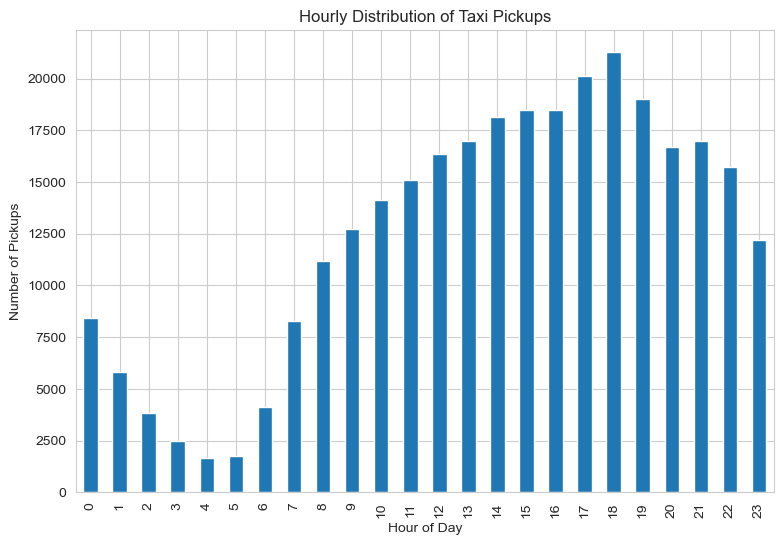

In [98]:
# Find and show the hourly trends in taxi pickups

hourly_pickups = df["pickup_hour"].value_counts().sort_index()

plt.figure(figsize=(9, 6))
hourly_pickups.plot(kind="bar")
plt.xlabel("Hour of Day")

plt.ylabel("Number of Pickups")
plt.title("Hourly Distribution of Taxi Pickups")
plt.show()


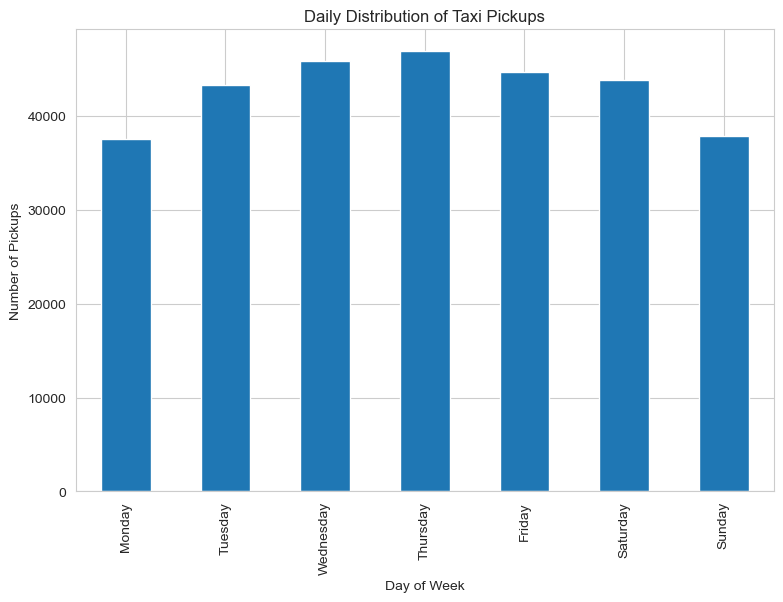

In [95]:
# Find and show the daily trends in taxi pickups (days of the week)
# Creating day of week from pickup datetime
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

# Order days properly
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
daily_pickups = df["pickup_day"].value_counts().reindex(day_order)

plt.figure(figsize=(9, 6))
daily_pickups.plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Number of Pickups")
plt.title("Daily Distribution of Taxi Pickups")
plt.show()



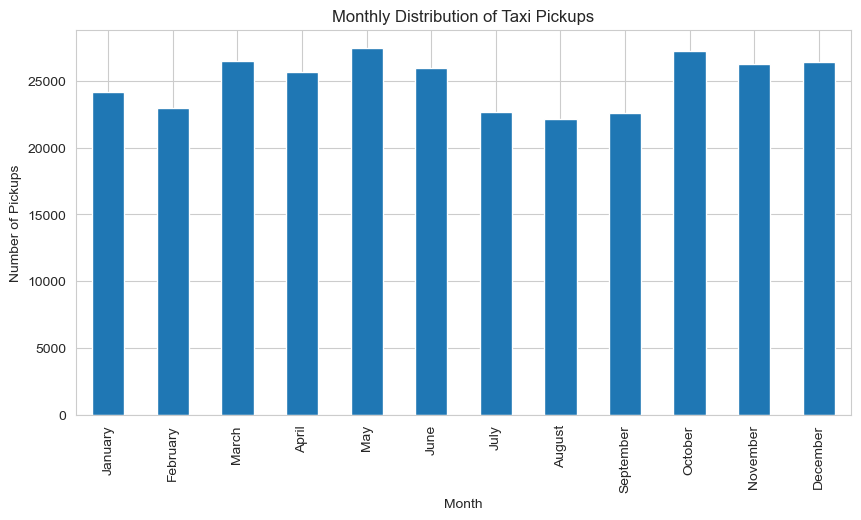

In [48]:
# Show the monthly trends in pickups
# Creating month from pickup datetime
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()

# Order months properly
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_pickups = df["pickup_month"].value_counts().reindex(month_order)

plt.figure(figsize=(10, 5))
monthly_pickups.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.title("Monthly Distribution of Taxi Pickups")
plt.show()



##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [49]:
# Analyse the above parameters
# Checking for negative values in key financial and distance columns
financial_cols = ["fare_amount", "tip_amount", "total_amount", "trip_distance"]
negative_summary = {
    col: (df[col] < 0).sum()
    for col in financial_cols
}
pd.DataFrame.from_dict(
    negative_summary,
    orient="index",
    columns=["negative_count"]
)



,negative_count
fare_amount,0
tip_amount,0
total_amount,0
trip_distance,0


In [50]:
# Checking for zero values in key financial and distance columns
zero_summary = {
    col: (df[col] == 0).sum()
    for col in financial_cols
}
pd.DataFrame.from_dict(
    zero_summary,
    orient="index",
    columns=["zero_count"]
)

,zero_count
fare_amount,88
tip_amount,68719
total_amount,46
trip_distance,5944


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [51]:
# Create a df with non zero entries for the selected parameters.
# For financial analysis, remove zero fare and zero total amount
df_non_zero = df[
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0)
]

# Keep trip_distance = 0 only if pickup and dropoff locations are the same

df_non_zero = df_non_zero[
    (df_non_zero["trip_distance"] > 0) |
    (df_non_zero["PULocationID"] == df_non_zero["DOLocationID"])
]
df_non_zero.shape



(296447, 22)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

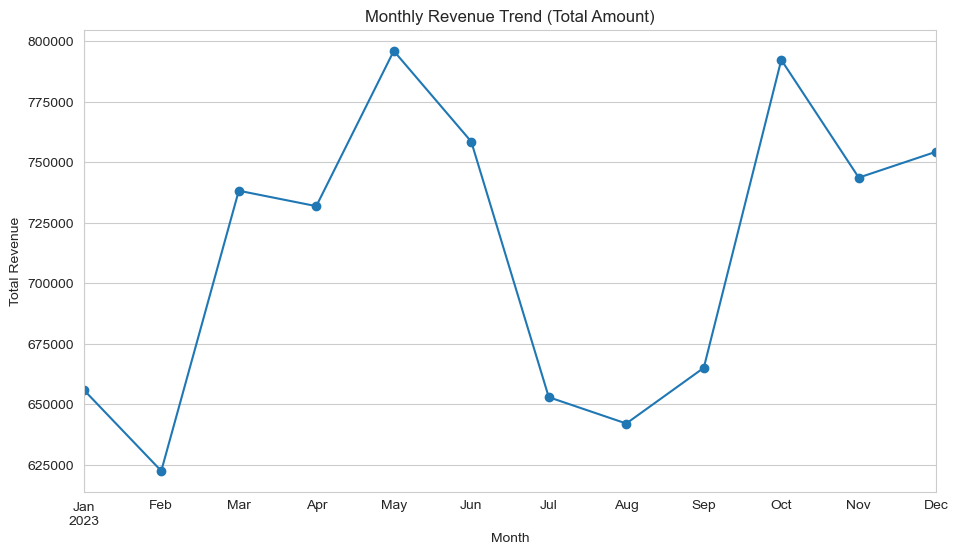

pickup_month
2023-01    655986.85
2023-02    622530.06
2023-03    738182.47
2023-04    731817.39
2023-05    795884.44
2023-06    758439.36
2023-07    652966.34
2023-08    642096.67
2023-09    665082.13
2023-10    792185.79
2023-11    743587.53
2023-12    754297.51
Freq: M, Name: total_amount, dtype: float64

In [94]:
# Group data by month and analyse monthly revenue
# Create month column
df_non_zero["pickup_month"] = df_non_zero["tpep_pickup_datetime"].dt.to_period("M")

# Aggregate total revenue per month
monthly_revenue = (
    df_non_zero
    .groupby("pickup_month")["total_amount"]
    .sum()
    .sort_index()
)
# Plot monthly revenue trend
plt.figure(figsize=(11, 6))
monthly_revenue.plot(kind="line", marker="o")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend (Total Amount)")
plt.grid(True)
plt.show()
monthly_revenue



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

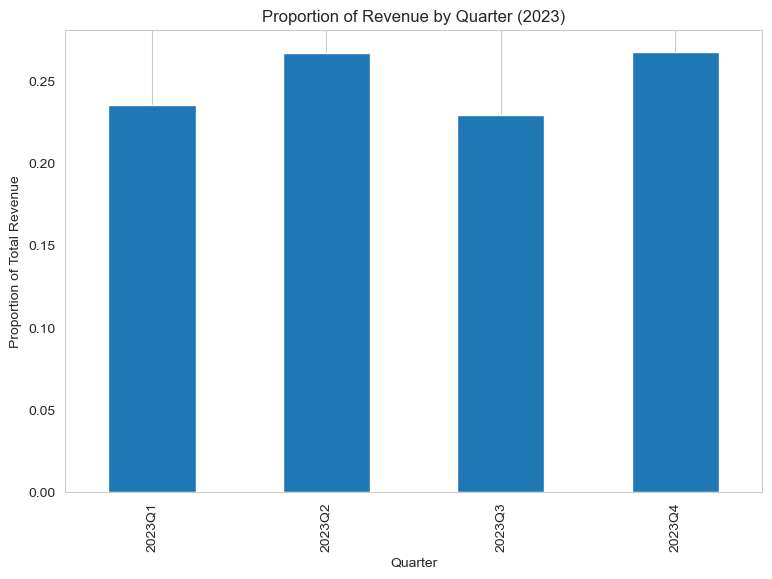

pickup_quarter
2023Q1    0.235787
2023Q2    0.267289
2023Q3    0.229175
2023Q4    0.267749
Freq: Q-DEC, Name: total_amount, dtype: float64

In [93]:
# Calculate proportion of each quarter
# Creating quarter column from pickup datetime
df_non_zero["pickup_quarter"] = df_non_zero["tpep_pickup_datetime"].dt.to_period("Q")

# Aggregate total revenue per quarter
quarterly_revenue = (
    df_non_zero
    .groupby("pickup_quarter")["total_amount"]
    .sum()
)
# Convert to proportion
quarterly_proportion = quarterly_revenue / quarterly_revenue.sum()

# Plot revenue proportion by quarter
plt.figure(figsize=(9, 6))
quarterly_proportion.plot(kind="bar")
plt.xlabel("Quarter")
plt.ylabel("Proportion of Total Revenue")
plt.title("Proportion of Revenue by Quarter (2023)")
plt.grid(axis="y")
plt.show()

quarterly_proportion


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

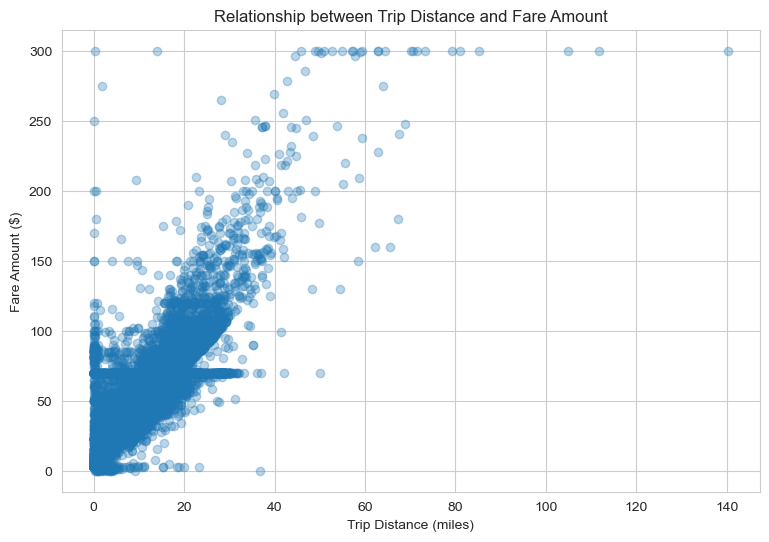

np.float64(0.9452232794831629)

In [92]:
# Show how trip fare is affected by distance
# Removing trips with zero distance (as suggested)
df_dist_fare = df_non_zero[df_non_zero["trip_distance"] > 0]

# Scatter plot: trip_distance vs fare_amount
plt.figure(figsize=(9, 6))
plt.scatter(
    df_dist_fare["trip_distance"],
    df_dist_fare["fare_amount"],
    alpha=0.3
)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Relationship between Trip Distance and Fare Amount")
plt.grid(True)
plt.show()
# Calculate correlation
correlation = df_dist_fare["trip_distance"].corr(df_dist_fare["fare_amount"])
correlation



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [55]:
# Convert to datetime if not already
df_non_zero["tpep_pickup_datetime"] = pd.to_datetime(
    df_non_zero["tpep_pickup_datetime"], errors="coerce"
)

df_non_zero["tpep_dropoff_datetime"] = pd.to_datetime(
    df_non_zero["tpep_dropoff_datetime"], errors="coerce"
)

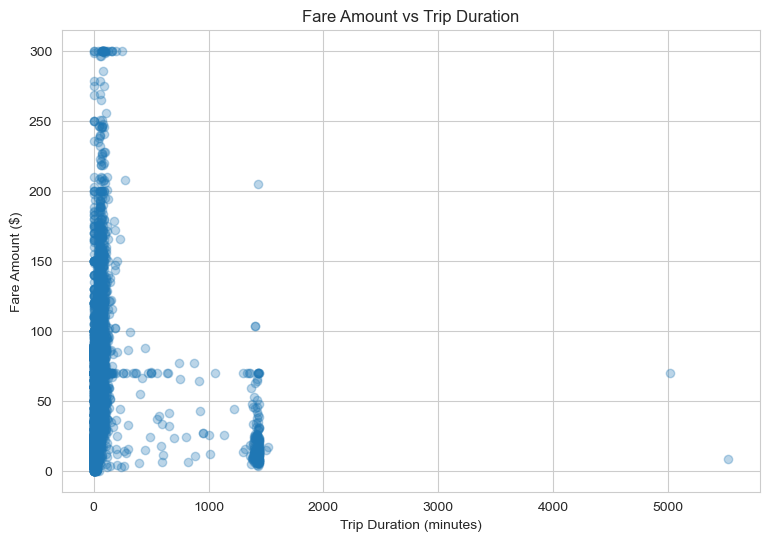

np.float64(0.26271047354015825)

In [91]:
# Show relationship between fare and trip duration
# Show relationship between fare and trip duration
# Create trip duration in minutes
df_non_zero["trip_duration"] = (
    df_non_zero["tpep_dropoff_datetime"] - df_non_zero["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Remove non-positive durations
df_non_zero = df_non_zero[df_non_zero["trip_duration"] > 0]

# Scatter plot: Fare vs Trip Duration
plt.figure(figsize=(9, 6))
plt.scatter(
    df_non_zero["trip_duration"],
    df_non_zero["fare_amount"],
    alpha=0.3
)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare Amount vs Trip Duration")
plt.grid(True)
plt.show()

# Correlation
fare_duration_corr = df_non_zero["fare_amount"].corr(df_non_zero["trip_duration"])
fare_duration_corr



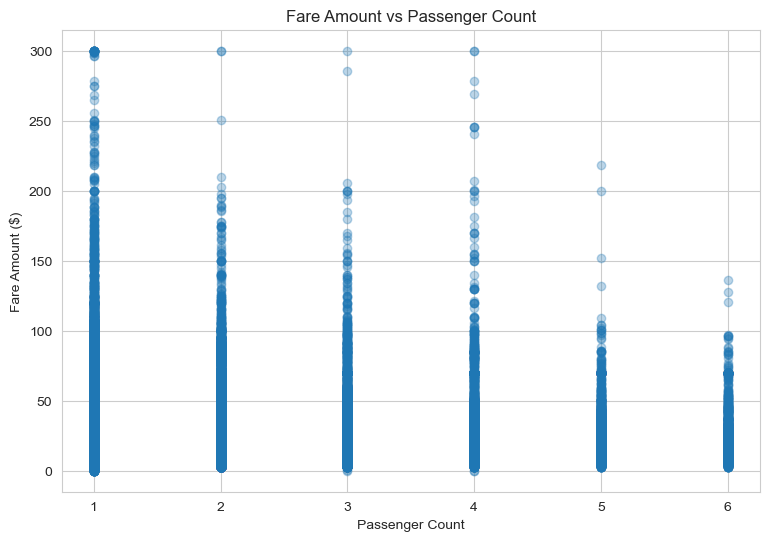

np.float64(0.04385505427684944)

In [90]:
# Show relationship between fare and number of passengers
# Scatter plot: Fare vs Passenger Count
plt.figure(figsize=(9, 6))
plt.scatter(
    df_non_zero["passenger_count"],
    df_non_zero["fare_amount"],
    alpha=0.3
)

plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount ($)")
plt.title("Fare Amount vs Passenger Count")
plt.grid(True)
plt.show()
# Correlation
fare_passenger_corr = df_non_zero["fare_amount"].corr(df_non_zero["passenger_count"])
fare_passenger_corr


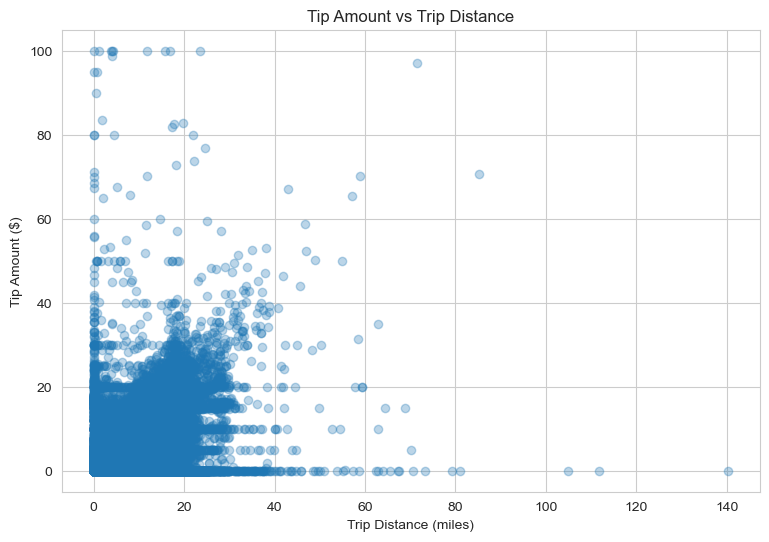

np.float64(0.5787126085603758)

In [89]:
# Show relationship between tip and trip distance
# Scatter plot: Tip vs Trip Distance
plt.figure(figsize=(9, 6))
plt.scatter(
    df_non_zero["trip_distance"],
    df_non_zero["tip_amount"],
    alpha=0.3
)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount ($)")
plt.title("Tip Amount vs Trip Distance")
plt.grid(True)
plt.show()

# Correlation
tip_distance_corr = df_non_zero["tip_amount"].corr(df_non_zero["trip_distance"])
tip_distance_corr



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [59]:
# Analyse the distribution of different payment types (payment_type).
payment_distribution = df_non_zero["payment_type"].value_counts().sort_index()

payment_distribution




payment_type
1.0    243210
2.0     49688
3.0      1355
4.0      2157
Name: count, dtype: int64

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



In [60]:
payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}
payment_distribution_labeled = payment_distribution.rename(index=payment_labels)

payment_distribution_labeled

payment_type
Credit Card    243210
Cash            49688
No Charge        1355
Dispute          2157
Name: count, dtype: int64

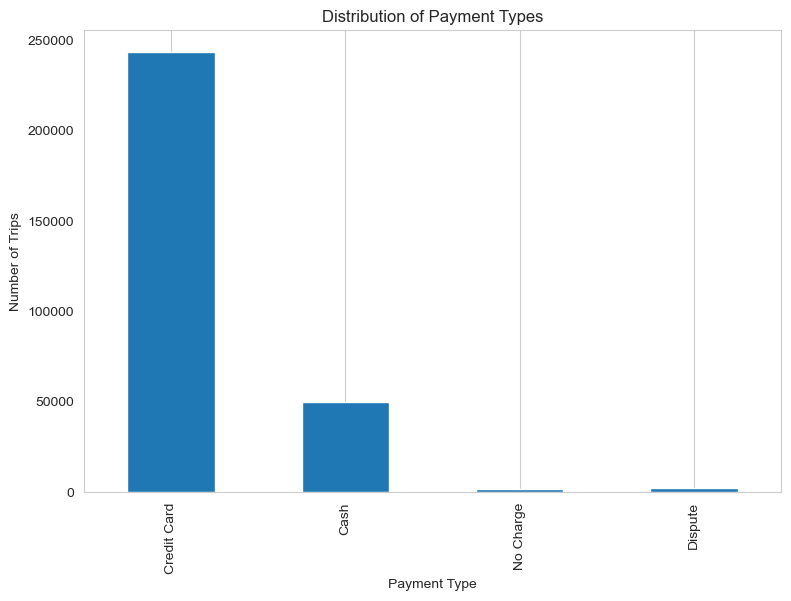

In [100]:
# Plot payment type distribution
plt.figure(figsize=(9, 6))
payment_distribution_labeled.plot(kind="bar")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.title("Distribution of Payment Types")
plt.grid(axis="y")
plt.show()

##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [62]:
# !pip install geopandas
!pip install geopandas


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 5.7 MB/s eta 0:00:04
   --- ------------------------------------ 2.1/22.9 MB 5.7 MB/s eta 0:00:04
   ----- ---------------------------------- 3.4/22.9 MB 5.9 MB/s eta 0:00:04
   -------- ------------------------------- 4.7/22.9 MB 6.0 MB/s eta 0:00:04
   ---------- ----------------------------- 6.0/22.9 MB 6.1 MB/s eta 0:00:03
   ------------ --------------------------- 7.3/22.9 MB 6.2 MB/s eta 0:00:03
   --------------- ------------------------ 8.9/22.9 MB 6.3 MB/s eta 0:00:03
   ----------------- ---------------------- 10.2/22.9 MB 6.3 MB/s eta 0:00:03
   -------------------- ------------------- 11.8/22.9 MB 6.4 MB/s eta 0:00:02
   ----------------------- ---------------- 13.4/22.9 MB 6.5 MB/s eta 0:00:02
   ------------------------- -------------- 14.7/22.9 MB 6.6 MB/s eta 0:00:02
   ---------------------------- ----------- 16.3/22.9 MB 6.6 MB/s eta 0:00:02
 

In [63]:
import sys
print(sys.executable)

C:\Users\Prakhar\anaconda3\Anaconda\python.exe


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [64]:
import os
os.getcwd()

'C:\\Users\\Prakhar\\OneDrive\\Desktop\\Datasets and Dictionary\\trip_records'

In [77]:
# import geopandas as gpd
# Import geopandas
import geopandas as gpd

# Path to your shapefile
file_path = (r"C:\Users\Prakhar\OneDrive\Desktop\Datasets and Dictionary\taxi_zones")

# Read shapefile
zones = gpd.read_file(file_path)

# Show first 5 rows
zones.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


The DataFrame contains columns such as OBJECTID, Shape_Leng, Shape_Area, zone, LocationID, borough, and geometry.

Here, LocationID is used to identify pickup and drop-off zones in the trip data. The geometric fields like Shape_Leng, Shape_Area, and geometry help in mapping and visualizing the zones.

You can easily display these zones on a map using the .plot() method.

In [78]:
# print(zones.info())
# zones.plot()
# Inspect zones GeoDataFrame
zones.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB


<Axes: >

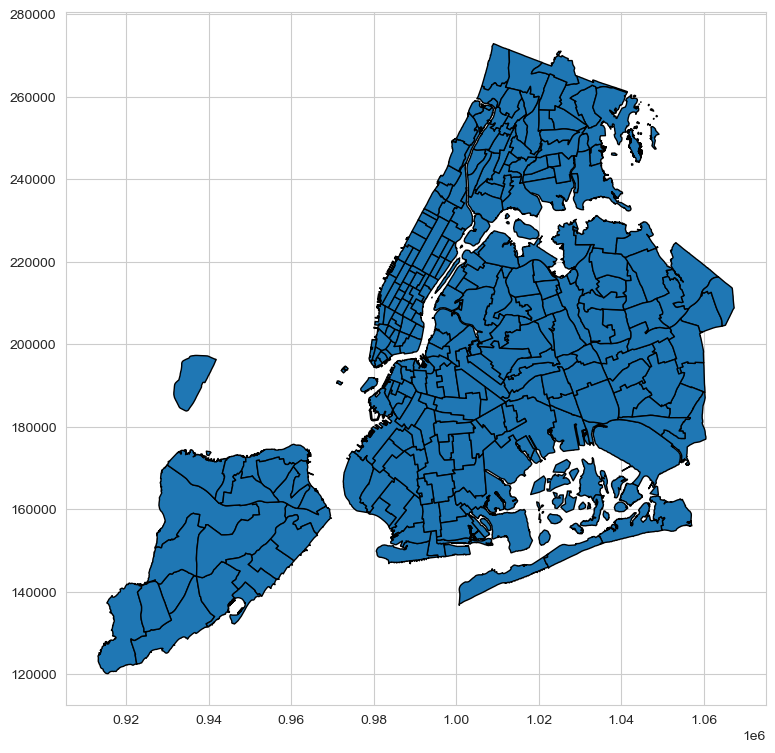

In [87]:
# Plot taxi zones map
zones.plot(figsize=(10, 9), edgecolor="black")

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [80]:
# Merge zones and trip records using locationID and PULocationID
df_with_zones = df_non_zero.merge(
    zones[["LocationID", "zone", "borough", "geometry"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)
df_with_zones.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee,pickup_hour,pickup_day,pickup_month,pickup_quarter,trip_duration,LocationID,zone,borough,geometry
0,1,2023-12-03 19:12:59,2023-12-03 19:33:13,1,2.80,1.0,N,100,143,1.0,...,0.0,19,Sunday,2023-12,2023Q4,20.233333,100.0,Garment District,Manhattan,"POLYGON ((987770.527 212686.678, 987638.873 21..."
1,2,2023-02-15 18:00:40,2023-02-15 18:15:04,1,1.12,1.0,N,50,161,2.0,...,0.0,18,Wednesday,2023-02,2023Q1,14.400000,50.0,Clinton West,Manhattan,"POLYGON ((985170.372 221087.389, 985817.17 220..."
2,2,2023-10-04 13:10:59,2023-10-04 13:18:59,1,1.08,1.0,N,142,48,2.0,...,0.0,13,Wednesday,2023-10,2023Q4,8.000000,142.0,Lincoln Square East,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
3,2,2023-02-12 00:24:05,2023-02-12 00:36:23,5,2.04,1.0,N,114,107,1.0,...,0.0,0,Sunday,2023-02,2023Q1,12.300000,114.0,Greenwich Village South,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20..."
4,2,2023-07-08 06:45:25,2023-07-08 07:15:57,1,19.33,1.0,N,113,132,1.0,...,0.0,6,Saturday,2023-07,2023Q3,30.533333,113.0,Greenwich Village North,Manhattan,"POLYGON ((986643.64 204346.324, 986592.535 204..."


In [81]:
df_with_zones[["PULocationID", "zone", "borough"]].sample(5)

,PULocationID,zone,borough
289191,43,Central Park,Manhattan
77507,246,West Chelsea/Hudson Yards,Manhattan
144450,138,LaGuardia Airport,Queens
88105,262,Yorkville East,Manhattan
23147,158,Meatpacking/West Village West,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [82]:
# Group data by location and calculate the number of trips
trip_counts = (
    df_with_zones
        .groupby("PULocationID")
        .size()
        .reset_index(name="trip_count")
)
trip_counts.head()



,PULocationID,trip_count
0,1,31
1,3,6
2,4,384
3,5,2
4,6,3


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [84]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(
    trip_counts,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)
# Replacing NaN trip counts with 0 (zones with no pickups)
zones_with_trips["trip_count"] = zones_with_trips["trip_count"].fillna(0)

zones_with_trips.head()




,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,31.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,6.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,384.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,2.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

<Axes: >

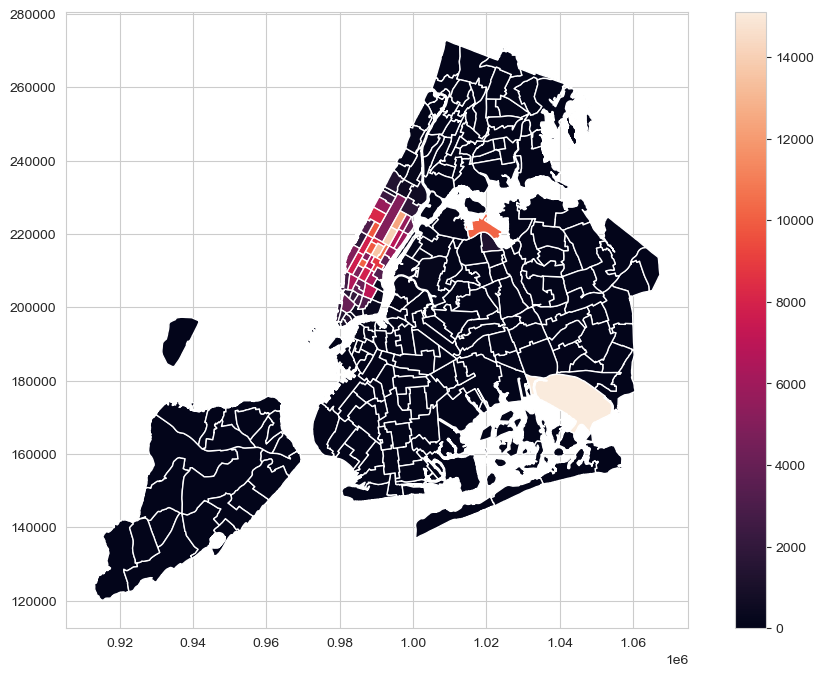

In [86]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 8))


# Plot the map and display it
zones_with_trips.plot(
    column="trip_count",
    ax=ax,
    legend=True
)



In [101]:
# can you try displaying the zones DF sorted by the number of trips?
# Display zones sorted by number of trips (descending)
zones_sorted = zones_with_trips.sort_values(by="trip_count", ascending=False)
zones_sorted[["LocationID", "zone", "borough", "trip_count"]].head(10)



,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,15105.0
236,237,Upper East Side South,Manhattan,13990.0
160,161,Midtown Center,Manhattan,13585.0
235,236,Upper East Side North,Manhattan,12395.0
161,162,Midtown East,Manhattan,10558.0
137,138,LaGuardia Airport,Queens,10171.0
185,186,Penn Station/Madison Sq West,Manhattan,10097.0
229,230,Times Sq/Theatre District,Manhattan,9911.0
141,142,Lincoln Square East,Manhattan,9810.0
169,170,Murray Hill,Manhattan,8754.0


In [102]:
# Top 10 zones with highest number of taxi trips
zones_sorted.tail(10)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
244,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",NaN,0.0
29,30,0.094510,0.000146,Broad Channel,30,Queens,"POLYGON ((1034013.272 163473.152, 1034866.459 ...",NaN,0.0
83,84,0.233624,0.002074,Eltingville/Annadale/Prince's Bay,84,Staten Island,"POLYGON ((939754.454 131548.91, 939802.804 131...",NaN,0.0
58,59,0.037795,0.000063,Crotona Park,59,Bronx,"POLYGON ((1014848.343 245121.005, 1015049.583 ...",NaN,0.0
98,99,0.183371,0.001210,Freshkills Park,99,Staten Island,"POLYGON ((937468.341 152998.406, 937320.263 15...",NaN,0.0
95,96,0.185180,0.000548,Forest Park/Highland Park,96,Queens,"POLYGON ((1029152.314 197379.274, 1029238.052 ...",NaN,0.0
175,176,0.151995,0.000658,Oakwood,176,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148...",NaN,0.0
45,46,0.134475,0.000926,City Island,46,Bronx,"MULTIPOLYGON (((1043853.395 252845.891, 104386...",NaN,0.0
198,199,0.077809,0.000289,Rikers Island,199,Bronx,"POLYGON ((1015023.713 230286.759, 1015093.307 ...",NaN,0.0
109,110,0.103946,0.000526,Great Kills Park,110,Staten Island,"POLYGON ((951420.092 139894.411, 951856.209 13...",NaN,0.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
Ans-Taxi pickups are at their lowest between 2 AM and 5 AM, then gradually rise throughout the day. Demand reaches its peak in the evening, particularly from 5 PM to 8 PM, likely due to office commutes and leisure activities. Weekdays generally record more pickups than weekends, with Thursday and Friday being the busiest. On a monthly basis, taxi activity is higher in late spring and fall, while February and August tend to have lower revenue and fewer trips.

* Trends in revenue collected
Ans-Monthly revenue generally mirrors the trend in pickup volumes. It reaches its highest levels in May and October, suggesting the influence of seasonal travel and tourism. In contrast, revenue declines during mid-summer in August and late winter in February.


* Trends in quarterly revenue
Ans-The second and fourth quarters generate the largest share of annual revenue, together contributing more than half of the total. The third quarter experiences a noticeable decline, possibly due to vacation periods and lower business travel. Overall, revenue is fairly evenly distributed across all quarters, reflecting steady demand throughout the year with slight seasonal variation.

* How fare depends on trip distance, trip duration and passenger counts
Ans-Fare amount is strongly positively correlated with trip distance, supporting the idea of distance-based pricing. It also has a moderate positive relationship with trip duration, although duration is not as strong a predictor as distance. Passenger count shows minimal correlation with fare, suggesting that pricing does not significantly depend on the number of passengers.

* How tip amount depends on trip distance
Ans-Tip amounts generally rise as trip distance increases, but they vary widely, indicating that tipping is affected by factors other than distance alone.

* Busiest zones
Ans-Pickup activity is highest in Manhattan and around major transportation hubs. Areas such as JFK Airport, LaGuardia Airport, Midtown, the Upper East Side, and Times Square record the most trips. In contrast, outer areas like parks, beaches, and low-density residential neighborhoods have very few or no pickups, as expected.



#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [103]:
# Find routes which have the slowest speeds at different times of the day
# Creating trip duration in hours
df_non_zero["trip_duration_hours"] = (
    (df_non_zero["tpep_dropoff_datetime"] - df_non_zero["tpep_pickup_datetime"])
        .dt.total_seconds() / 3600
)
# Removing invalid durations
df_non_zero = df_non_zero[df_non_zero["trip_duration_hours"] > 0]
# Calculating average speed by route and hour
route_speed = (
    df_non_zero
        .groupby(["PULocationID", "DOLocationID", "pickup_hour"])
        .agg(
            avg_distance=("trip_distance", "mean"),
            avg_duration=("trip_duration_hours", "mean")
        )
        .reset_index()
)
# Speed = distance / duration
route_speed["avg_speed_mph"] = (
    route_speed["avg_distance"] / route_speed["avg_duration"]
)
route_speed.head()



,PULocationID,DOLocationID,pickup_hour,avg_distance,avg_duration,avg_speed_mph
0,1,1,6,0.5,0.029514,16.941176
1,1,1,7,0.0,0.004722,0.000000
2,1,1,8,0.0,0.016667,0.000000
3,1,1,14,0.0,0.004611,0.000000
4,1,1,15,0.0,0.002500,0.000000


In [104]:
# Filter meaningful routes
route_speed_filtered = route_speed[
    (route_speed["avg_distance"] > 1) &
    (route_speed["avg_speed_mph"] > 0)
    ]
# Find slowest routes
slowest_routes = (
    route_speed_filtered
        .sort_values("avg_speed_mph")
        .head(10)
)
slowest_routes

,PULocationID,DOLocationID,pickup_hour,avg_distance,avg_duration,avg_speed_mph
5687,50,43,8,1.420000,23.855556,0.059525
39368,163,140,6,1.990000,23.936389,0.083137
43612,181,132,20,2.290000,24.996944,0.091611
47564,226,226,6,1.490000,13.946065,0.106840
60277,249,79,4,1.300000,11.873056,0.109492
30666,142,230,6,1.340000,11.989444,0.111765
56509,237,264,22,1.385000,11.695694,0.118420
33379,148,100,10,2.940000,23.110556,0.127215
46141,211,52,18,3.170000,23.848889,0.132920
35348,158,114,16,1.163333,8.094352,0.143722


In [105]:
# Merging pickup zone names
slowest_routes = slowest_routes.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename(columns={"zone": "pickup_zone", "borough": "pickup_borough"})

# Merging drop-off zone names
slowest_routes = slowest_routes.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename(columns={"zone": "dropoff_zone", "borough": "dropoff_borough"})
slowest_routes[
    ["pickup_zone", "dropoff_zone", "pickup_hour", "avg_speed_mph"]
    ]

,pickup_zone,dropoff_zone,pickup_hour,avg_speed_mph
0,Clinton West,Central Park,8,0.059525
1,Midtown North,Lenox Hill East,6,0.083137
2,Park Slope,JFK Airport,20,0.091611
3,Sunnyside,Sunnyside,6,0.106840
4,West Village,East Village,4,0.109492
5,Lincoln Square East,Times Sq/Theatre District,6,0.111765
6,Upper East Side South,NaN,22,0.118420
7,Lower East Side,Garment District,10,0.127215
8,SoHo,Cobble Hill,18,0.132920
9,Meatpacking/West Village West,Greenwich Village South,16,0.143722


How does identifying high-traffic, high-demand routes help us?
Ans-Identifying high-traffic, high-demand routes improves operational efficiency and customer experience. The analysis shows that some pickup–dropoff pairs have very low average speeds during certain hours, indicating congestion.

This insight helps fleets position drivers in busy areas during peak times to reduce wait times, manage congestion by suggesting alternative routes, and improve ETA accuracy using time-based speed patterns. It also supports dynamic pricing or driver incentives on slow, high-demand routes and provides valuable data for urban planning by highlighting persistent traffic bottlenecks.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [106]:
# Visualise the number of trips per hour and find the busiest hour
# Count trips per hour (sampled data)
hourly_trips_sampled = df_non_zero["pickup_hour"].value_counts().sort_index()

# Scale up using sampling ratio
# (adjust this if your sampling ratio is different)
sampling_ratio = 0.1 # e.g. 10% sample
hourly_trips_actual = hourly_trips_sampled / sampling_ratio
hourly_trips_actual



pickup_hour
0      82520.0
1      56930.0
2      37310.0
3      24070.0
4      16020.0
5      16980.0
6      40540.0
7      81330.0
8     110420.0
9     126380.0
10    140330.0
11    149840.0
12    162180.0
13    167770.0
14    179870.0
15    183100.0
16    182950.0
17    198730.0
18    209880.0
19    188200.0
20    165250.0
21    168210.0
22    155120.0
23    120170.0
Name: count, dtype: float64

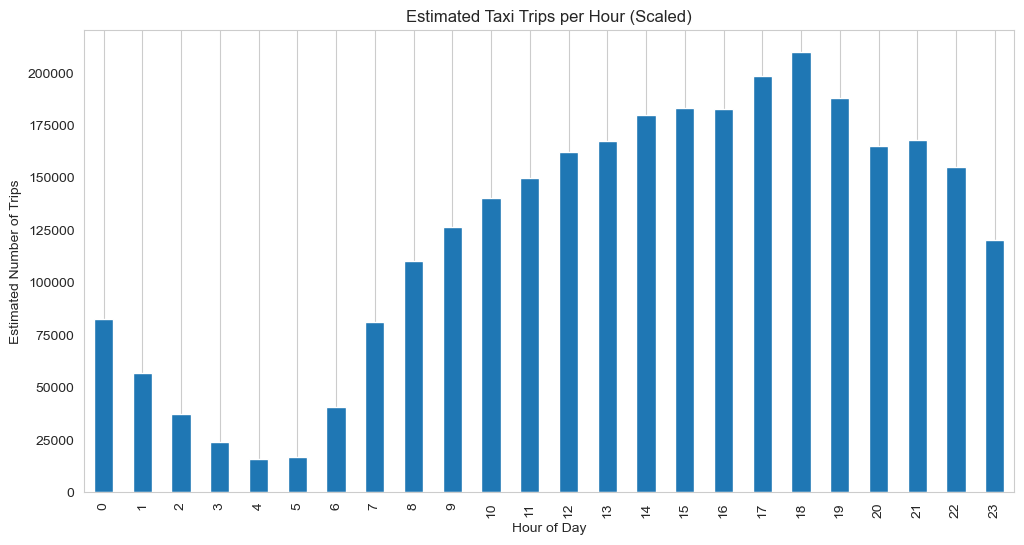

In [108]:
plt.figure(figsize=(12, 6))
hourly_trips_actual.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Estimated Number of Trips")
plt.title("Estimated Taxi Trips per Hour (Scaled)")
plt.grid(axis="y")
plt.show()

In [109]:
# Finding busiest hour
busiest_hour = hourly_trips_actual.idxmax()
busiest_trips = hourly_trips_actual.max()

busiest_hour, busiest_trips

(np.int32(18), 209880.0)

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [110]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =0.10



In [111]:
# Number of trips per hour 
hourly_trips_sampled = df_non_zero["pickup_hour"].value_counts().sort_index()

In [112]:
# Scale up to actual estimated trips
hourly_trips_actual = hourly_trips_sampled / sample_fraction

In [113]:
# Find the five busiest hours
top_5_hours = hourly_trips_actual.sort_values(ascending=False).head(5)
top_5_hours

pickup_hour
18    209880.0
17    198730.0
19    188200.0
15    183100.0
16    182950.0
Name: count, dtype: float64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

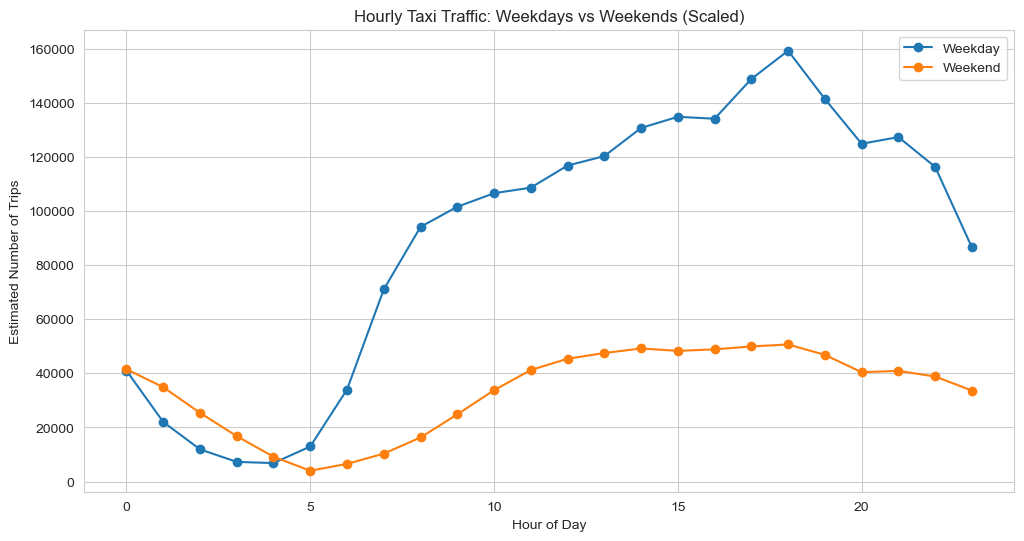

day_type,Weekday,Weekend
pickup_hour,,
0,41010.0,41510.0
1,22040.0,34890.0
2,11910.0,25400.0
3,7280.0,16790.0
4,6830.0,9190.0
5,12970.0,4010.0
6,34000.0,6540.0
7,71010.0,10320.0
8,94120.0,16300.0


In [115]:
# Compare traffic trends for the week days and weekends
# Sampling fraction used earlier
sample_fraction = 0.10

# Create day type: Weekday vs Weekend
df_non_zero["day_type"] = df_non_zero["tpep_pickup_datetime"].dt.weekday.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)
# Hourly trips by day type (sampled)
hourly_daytype = (
    df_non_zero
        .groupby(["day_type", "pickup_hour"])
        .size()
        .unstack(0)
        .fillna(0)
)
# Scale to actual estimated trips

hourly_daytype_actual = hourly_daytype / sample_fraction
# Plot comparison
plt.figure(figsize=(12, 6))
hourly_daytype_actual["Weekday"].plot(label="Weekday", marker="o")
hourly_daytype_actual["Weekend"].plot(label="Weekend", marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Estimated Number of Trips")
plt.title("Hourly Taxi Traffic: Weekdays vs Weekends (Scaled)")

plt.legend()
plt.grid(True)
plt.show()
hourly_daytype_actual



What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?
Travel behavior patterns differ clearly between weekdays and weekends.

Ans-On weekdays, taxi demand rises sharply between 7–9 AM due to office commutes and peaks again from 5–7 PM during evening travel, before dropping late at night.
On weekends, morning demand is much lower, increases gradually from late morning, and stays steady through the afternoon and evening, with peak hours occurring later in the day, reflecting leisure-focused travel rather than work commutes.
Overall, weekdays show strong commute-driven peaks, while weekends display flatter, leisure-driven demand patterns, supporting better customer experience, smarter pricing, and efficient resource allocation.

Recognizing busy and quiet hours offers multiple benefits, including optimized fleet deployment, shorter passenger wait times, dynamic pricing and incentives, efficient driver shift planning, and valuable insights for traffic management and urban planning.



**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [116]:
# Find top 10 pickup and dropoff zones# Find top 10 pickup and dropoff zones
# Top 10 pickup zones
top_pickup_zones = (
    df_non_zero.groupby("PULocationID")
        .size()
        .sort_values(ascending=False)
        .head(10)
)
# Top 10 dropoff zones
top_dropoff_zones = (
    df_non_zero.groupby("DOLocationID")
        .size()
        .sort_values(ascending=False)
        .head(10)
)
# Hourly pickup trends for top pickup zones
pickup_trends = (
    df_non_zero[df_non_zero["PULocationID"].isin(top_pickup_zones.index)]
        .groupby(["pickup_hour", "PULocationID"])
        .size()
        .unstack(fill_value=0)
    / sample_fraction
)
# Hourly dropoff trends for top dropoff zones
dropoff_trends = (
    df_non_zero[df_non_zero["DOLocationID"].isin(top_dropoff_zones.index)]
        .groupby(["pickup_hour", "DOLocationID"])
        .size()
        .unstack(fill_value=0)
    / sample_fraction
)
pickup_trends.head(), dropoff_trends.head()



(PULocationID     132     138     142     161     162     170     186     230  \
 pickup_hour                                                                    
 0             5900.0  2260.0  1480.0  2230.0  1550.0  1850.0  2440.0  3400.0   
 1             3130.0   420.0   610.0   890.0   770.0   970.0  1520.0  1890.0   
 2             1020.0    90.0   290.0   360.0   620.0   490.0   900.0  1070.0   
 3              700.0    80.0   110.0   250.0   180.0   260.0   480.0   620.0   
 4              470.0    80.0   170.0   280.0   280.0   260.0   380.0   760.0   
 
 PULocationID    236     237  
 pickup_hour                  
 0             580.0  1430.0  
 1             360.0   510.0  
 2             100.0   250.0  
 3              50.0   160.0  
 4             150.0   180.0  ,
 DOLocationID     68      141     142     161     162     170     230     236  \
 pickup_hour                                                                    
 0             2120.0  1790.0  1620.0  1200.0  1350

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [117]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Pickup counts per zone
pickup_counts = df_non_zero.groupby("PULocationID").size()

# Dropoff counts per zone
dropoff_counts = df_non_zero.groupby("DOLocationID").size()

# Combine into one DataFrame
pickup_dropoff_ratio = (
    pd.DataFrame({
        "pickups": pickup_counts,
        "dropoffs": dropoff_counts
    })
        .fillna(0)
)

# Avoid division by zero
pickup_dropoff_ratio = pickup_dropoff_ratio[pickup_dropoff_ratio["dropoffs"] > 0]

# Compute ratio
pickup_dropoff_ratio["pickup_dropoff_ratio"] = (
    pickup_dropoff_ratio["pickups"] / pickup_dropoff_ratio["dropoffs"]
)

# Top 10 highest ratios
top_10_highest = pickup_dropoff_ratio.sort_values(
    "pickup_dropoff_ratio", ascending=False
).head(10)

# Top 10 lowest ratios
top_10_lowest = pickup_dropoff_ratio.sort_values(
    "pickup_dropoff_ratio", ascending=True
).head(10)

top_10_highest, top_10_lowest



(     pickups  dropoffs  pickup_dropoff_ratio
 70    1336.0       174              7.678161
 132  15105.0      3459              4.366869
 138  10171.0      3934              2.585409
 186  10097.0      6278              1.608315
 43    4962.0      3629              1.367319
 249   6520.0      4796              1.359466
 114   3823.0      2833              1.349453
 162  10558.0      8336              1.266555
 100   4960.0      4028              1.231380
 163   8649.0      7303              1.184308,
      pickups  dropoffs  pickup_dropoff_ratio
 176      0.0         3                   0.0
 96       0.0        10                   0.0
 101      0.0        24                   0.0
 109      0.0         6                   0.0
 111      0.0         2                   0.0
 115      0.0         4                   0.0
 118      0.0         5                   0.0
 58       0.0         4                   0.0
 57       0.0         3                   0.0
 128      0.0        22          

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [118]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
# Defining night hours (11 PM to 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

night_trips = df_non_zero[df_non_zero["pickup_hour"].isin(night_hours)]

# Top 10 pickup zones at night
top_night_pickups = (
    night_trips.groupby("PULocationID")
        .size()
        .sort_values(ascending=False)
        .head(10)
    / sample_fraction
)

# Top 10 dropoff zones at night
top_night_dropoffs = (
    night_trips.groupby("DOLocationID")
        .size()
        .sort_values(ascending=False)
        .head(10)
    / sample_fraction
)
top_night_pickups, top_night_dropoffs



(PULocationID
 79     25120.0
 132    22320.0
 249    20810.0
 48     16530.0
 148    15660.0
 114    14480.0
 230    13390.0
 186    11000.0
 164    10150.0
 68      9780.0
 dtype: float64,
 DOLocationID
 79     14000.0
 48     11470.0
 170    10060.0
 68      9370.0
 107     8990.0
 141     8340.0
 263     7930.0
 148     7690.0
 239     7610.0
 249     7600.0
 dtype: float64)

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [120]:
# Filter for night hours (11 PM to 5 AM)
night_hours = (df_non_zero["pickup_hour"] >= 23) | (df_non_zero["pickup_hour"] <= 5)

# Calculate total revenue
total_revenue = df_non_zero["total_amount"].sum()

# Night time revenue
night_revenue = df_non_zero.loc[night_hours, "total_amount"].sum()

# Day time revenue
day_revenue = total_revenue - night_revenue

# Revenue share
revenue_share = pd.Series(
    {
        "Nighttime Revenue Share": night_revenue / total_revenue,
        "Daytime Revenue Share": day_revenue / total_revenue
    }
)
revenue_share



Nighttime Revenue Share    0.122549
Daytime Revenue Share      0.877451
dtype: float64

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [121]:
# Analyse the fare per mile per passenger for different passenger counts
# Avoid divide-by-zero trips
df_fare_mile = df_non_zero[df_non_zero["trip_distance"] > 0].copy()

# Fare per mile
df_fare_mile["fare_per_mile"] = df_fare_mile["fare_amount"] / df_fare_mile["trip_distance"]

# Fare per mile per passenger
df_fare_mile["fare_per_mile_per_passenger"] = (
    df_fare_mile["fare_per_mile"] / df_fare_mile["passenger_count"]
)

# Average fare per mile per passenger by passenger count
avg_fare_per_mile_per_passenger = (
    df_fare_mile
        .groupby("passenger_count")["fare_per_mile_per_passenger"]
        .mean()
)
avg_fare_per_mile_per_passenger




passenger_count
1    10.924532
2     6.343051
3     3.345266
4     4.627358
5     1.922471
6     1.354941
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

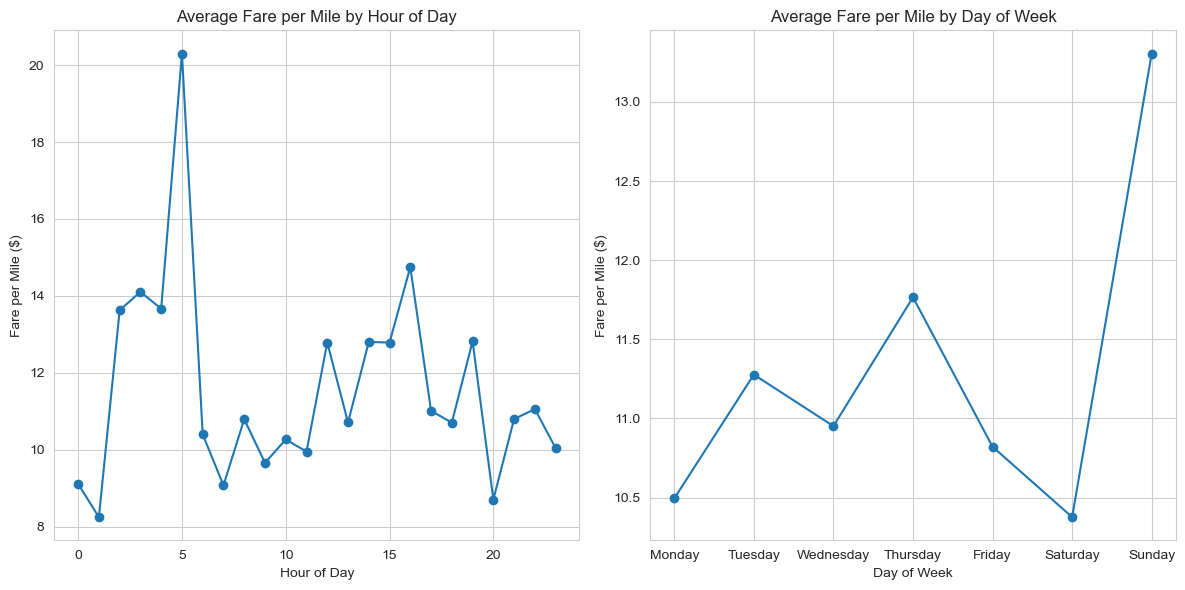

(pickup_hour
 0      9.114897
 1      8.252876
 2     13.630107
 3     14.105932
 4     13.667321
 5     20.299734
 6     10.402490
 7      9.079814
 8     10.797689
 9      9.662924
 10    10.271642
 11     9.955093
 12    12.790065
 13    10.711936
 14    12.804597
 15    12.789671
 16    14.749069
 17    11.016730
 18    10.706561
 19    12.821142
 20     8.709482
 21    10.800376
 22    11.060314
 23    10.047823
 Name: fare_per_mile, dtype: float64,
 pickup_day
 Monday       10.494133
 Tuesday      11.276969
 Wednesday    10.951312
 Thursday     11.765110
 Friday       10.821206
 Saturday     10.376366
 Sunday       13.305615
 Name: fare_per_mile, dtype: float64)

In [122]:
# Compare the average fare per mile for different days and for different times of the day
# Reuse fare_per_mile dataframe (already excludes zero distance)
df_fpm = df_fare_mile.copy()

# Add pickup hour and day name
df_fpm["pickup_hour"] = df_fpm["tpep_pickup_datetime"].dt.hour
df_fpm["pickup_day"] = df_fpm["tpep_pickup_datetime"].dt.day_name()

# Average fare per mile by hour of day
avg_fpm_hour = (
    df_fpm
        .groupby("pickup_hour")["fare_per_mile"]
        .mean()
)

# Average fare per mile by day of week (ordered)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_fpm_day = (
    df_fpm
        .groupby("pickup_day")["fare_per_mile"]
        .mean()
        .reindex(day_order)
)
# Plot comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
avg_fpm_hour.plot(marker="o")
plt.title("Average Fare per Mile by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fare per Mile ($)")
plt.grid(True)

plt.subplot(1, 2, 2)
avg_fpm_day.plot(marker="o")
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fare per Mile ($)")
plt.grid(True)
plt.tight_layout()
plt.show()
avg_fpm_hour, avg_fpm_day


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [123]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour',
       'pickup_day', 'pickup_month'],
      dtype='object')

<Figure size 1200x600 with 0 Axes>

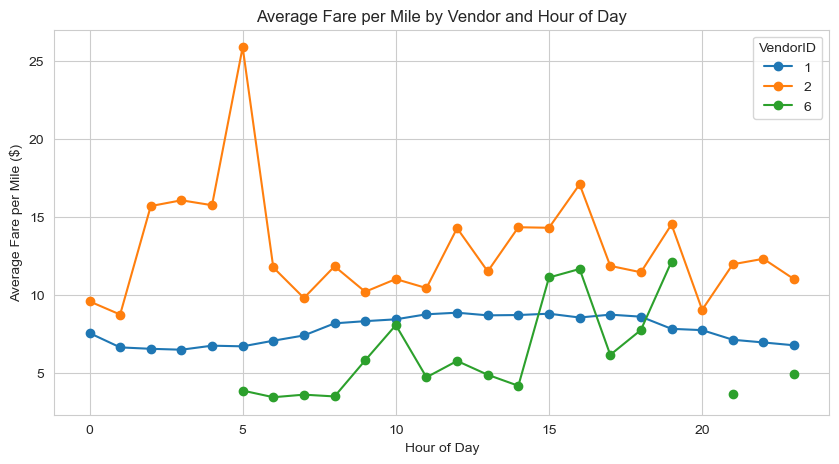

VendorID,1,2,6
pickup_hour,,,
0,7.539638,9.574048,NaN
1,6.619929,8.727718,NaN
2,6.528971,15.691004,NaN
3,6.470551,16.060589,NaN
4,6.729560,15.745187,NaN
5,6.686966,25.885245,3.847665
6,7.048130,11.749708,3.421163
7,7.386025,9.790742,3.585944
8,8.162553,11.822428,3.471811


In [125]:
# Compare fare per mile for different vendors
# Ensure fare_per_mile exists and valid trips only
df_vendor_fpm = df_non_zero[df_non_zero["trip_distance"] > 0].copy()
df_vendor_fpm["fare_per_mile"] = (
    df_vendor_fpm["fare_amount"] / df_vendor_fpm["trip_distance"]
)

# Extract pickup hour
df_vendor_fpm["pickup_hour"] = df_vendor_fpm["tpep_pickup_datetime"].dt.hour

# Average fare per mile by vendor and hour
vendor_hour_fpm = (
    df_vendor_fpm
        .groupby(["VendorID", "pickup_hour"])["fare_per_mile"]
        .mean()
        .unstack(0)
)
# Plot
plt.figure(figsize=(12, 6))
vendor_hour_fpm.plot(marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile ($)")
plt.title("Average Fare per Mile by Vendor and Hour of Day")
plt.grid(True)
plt.legend(title="VendorID")
plt.show()
vendor_hour_fpm



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [126]:
# Defining distance tiers
# Keeping valid trips only
df_tier = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0)
    ].copy()

# Fare per mile
df_tier["fare_per_mile"] = df_tier["fare_amount"] / df_tier["trip_distance"]

# Define distance tiers
df_tier["distance_tier"] = pd.cut(
    df_tier["trip_distance"],
    bins=[0, 2, 5, float("inf")],
    labels=["0–2 miles", "2–5 miles", "5+ miles"]
)
# Average fare per mile by vendor and distance tier
vendor_distance_fpm = (
    df_tier
        .groupby(["VendorID", "distance_tier"])["fare_per_mile"]
        .mean()
        .unstack()
)
vendor_distance_fpm



distance_tier,0–2 miles,2–5 miles,5+ miles
VendorID,,,
1,9.886650,6.380006,4.429599
2,18.041134,6.542910,4.489117
6,20.130726,7.729275,4.624177


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [127]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Keeping valid trips
df_tip = df[
    (df["fare_amount"] > 0) &
    (df["trip_distance"] > 0)
    ].copy()

# Tip percentage
df_tip["tip_pct"] = (df_tip["tip_amount"] / df_tip["fare_amount"]) * 100

# Pickup hour
df_tip["pickup_hour"] = df_tip["tpep_pickup_datetime"].dt.hour

# Distance tiers
df_tip["distance_tier"] = pd.cut(
    df_tip["trip_distance"],
    bins=[0, 2, 5, float("inf")],
    labels=["0–2 miles", "2–5 miles", "5+ miles"]
)

# Average tip % by distance, passengers, and hour
tip_summary = (
    df_tip
        .groupby(["distance_tier", "passenger_count", "pickup_hour"])["tip_pct"]
        .mean()
        .reset_index()
)
tip_summary.head()



,distance_tier,passenger_count,pickup_hour,tip_pct
0,0–2 miles,1,0,22.849907
1,0–2 miles,1,1,24.027925
2,0–2 miles,1,2,22.340717
3,0–2 miles,1,3,24.776959
4,0–2 miles,1,4,22.146022


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [137]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Calculate average values for low tip trips
low_avg = low_tips[["trip_distance", "passenger_count", "pickup_hour"]].mean()

# Calculate average values for high tip trips
high_avg = high_tips[["trip_distance", "passenger_count", "pickup_hour"]].mean()

# Combine into a comparison DataFrame
comparison = pd.DataFrame({
    "Low Tip Trips (<10%)": low_avg,
    "High Tip Trips (>25%)": high_avg
})

# Display the result
print(comparison)

                 Low Tip Trips (<10%)  High Tip Trips (>25%)
trip_distance                3.914756               2.305755
passenger_count              1.415872               1.358835
pickup_hour                 13.910150              14.590292


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

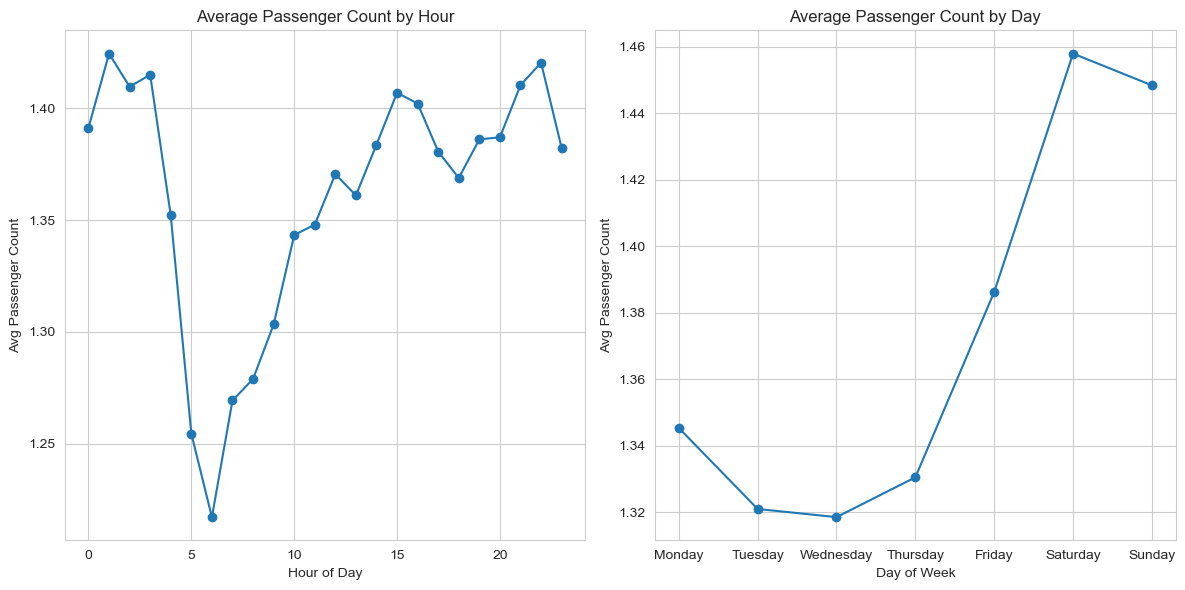

(pickup_hour
 0     1.391273
 1     1.424535
 2     1.409699
 3     1.415071
 4     1.352087
 5     1.254441
 6     1.217066
 7     1.269277
 8     1.278893
 9     1.303290
 10    1.343328
 11    1.347956
 12    1.370594
 13    1.361080
 14    1.383759
 15    1.407008
 16    1.402187
 17    1.380697
 18    1.368849
 19    1.386139
 20    1.387081
 21    1.410388
 22    1.420467
 23    1.382278
 Name: passenger_count, dtype: float64,
 pickup_day
 Monday       1.345326
 Tuesday      1.320934
 Wednesday    1.318475
 Thursday     1.330446
 Friday       1.386240
 Saturday     1.457957
 Sunday       1.448401
 Name: passenger_count, dtype: float64)

In [144]:
# See how passenger count varies across hours and days
#Create pickup hour and pickup day
df_pc = df.copy()
df_pc["pickup_hour"] = df_pc["tpep_pickup_datetime"].dt.hour
df_pc["pickup_day"] = df_pc["tpep_pickup_datetime"].dt.day_name()

# Average passenger count by hour
avg_passenger_hour = (
    df_pc
        .groupby("pickup_hour")["passenger_count"]
        .mean()
)

# Average passenger count by day
avg_passenger_day = (
    df_pc
        .groupby("pickup_day")["passenger_count"]
        .mean()
        .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
                )
# Plot
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
avg_passenger_hour.plot(marker="o")
plt.title("Average Passenger Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Passenger Count")
plt.grid(True)
plt.subplot(1,2,2)
avg_passenger_day.plot(marker="o")
plt.title("Average Passenger Count by Day")
plt.xlabel("Day of Week")
plt.ylabel("Avg Passenger Count")
plt.grid(True)
plt.tight_layout()
plt.show()
avg_passenger_hour, avg_passenger_day




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [145]:
# How does passenger count vary across zones
passenger_by_zone = (
    df
        .groupby("PULocationID")["passenger_count"]
        .mean()
        .sort_values(ascending=False)
)
passenger_by_zone



PULocationID
178    2.666667
150    2.500000
6      2.333333
196    1.733333
195    1.666667
         ...   
165    1.000000
62     1.000000
160    1.000000
67     1.000000
139    1.000000
Name: passenger_count, Length: 239, dtype: float64

In [146]:
zones_with_trips.columns

Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry', 'PULocationID', 'trip_count'],
      dtype='object')

In [149]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_passenger_by_zone = (
    df
        .groupby("PULocationID")["passenger_count"]
        .mean()
        .reset_index()
)
zones_with_trips = zones_with_trips.merge(
    avg_passenger_by_zone,
    on="PULocationID",
    how="left"
)
zones_with_trips.rename(columns={"passenger_count": "avg_passenger_count"}, inplace=True)
zones_with_trips[["zone", "avg_passenger_count"]].drop_duplicates()



,zone,avg_passenger_count
0,Newark Airport,1.617647
1,Jamaica Bay,NaN
2,Allerton/Pelham Gardens,1.000000
3,Alphabet City,1.320099
4,Arden Heights,1.000000
...,...,...
258,Woodlawn/Wakefield,1.166667
259,Woodside,1.242424
260,World Trade Center,1.512787
261,Yorkville East,1.311815


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [150]:
# How often is each surcharge applied?
surcharge_cols = [
    "extra",
    "mta_tax",
    "tolls_amount",
    "congestion_surcharge",
    "airport_fee"
]



In [151]:
#Flag trips with any surcharge applied
df["any_surcharge"] = df[surcharge_cols].gt(0).any(axis=1)

In [152]:
# Surcharge frequency by pickup zone
surcharge_by_zone = (
    df
        .groupby("PULocationID")["any_surcharge"]
        .mean()
        .sort_values(ascending=False)
)
surcharge_by_zone

PULocationID
139    1.000000
189    1.000000
178    1.000000
182    1.000000
89     1.000000
         ...   
183    0.666667
201    0.666667
265    0.545064
1      0.294118
251    0.000000
Name: any_surcharge, Length: 239, dtype: float64

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

Ans-Exploratory analysis of the 2023 NYC Yellow Taxi data reveals clear patterns in demand, pricing, and passenger behavior. Taxi demand peaks during weekday mornings (7–10 AM) and evenings (4–8 PM), with Fridays busiest, while weekends see lower, flatter demand. Monthly trends show moderate increases in spring and fall.
Revenue is mainly driven by trip distance, with fare per mile decreasing on longer trips due to base fares. Most rides have a single passenger, though airports and commercial hubs see higher occupancy. Surcharges, tolls, and fees are concentrated in central districts, airports, and peak hours, highlighting the influence of time and location on cost.
These insights can inform better routing, fleet deployment, and dynamic pricing strategies.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Ans-Taxi routing and dispatch can be optimized by matching vehicle availability to demand patterns. Fleet deployment should be increased during weekday morning and evening peaks, especially in busy business districts and transit hubs, while reduced overnight when demand is low. Dynamic routing in congestion-prone areas can minimize idle time and avoid bottlenecks, particularly during peak hours with surcharges. Using historical pickup data and time-based demand forecasts helps reduce empty trips, cut fuel costs, and improve trip efficiency.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Ans-Cab positioning should focus on zones with consistently high pickups and passenger counts, such as airports, commercial hubs, and central Manhattan, for proactive vehicle staging. Low-demand areas can rely on on-demand relocation. Seasonal trends suggest increasing fleet presence during peak months and reducing it during slower periods, ensuring efficient asset use while maintaining citywide service coverage.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Ans-Short trips are disproportionately impacted by base fares, while longer trips have lower average fare per mile. Pricing strategies can be improved by reducing base fare effects during off-peak times or offering short-trip incentives. Clear communication of surcharges in congestion zones and airports, along with targeted promotions in low-demand periods or underutilized areas, can boost customer satisfaction and stimulate demand. Distance-based pricing insights help balance competitiveness and profitability.

Conclusion

To capture overall taxi demand patterns, a 5% hourly stratified sample was assumed sufficient. Trips with zero fare or total amounts were treated as errors or cancellations and excluded from financial analysis, while zero tips were retained as valid entries. Short trips showing zero distance but with the same pickup and dropoff zones were considered legitimate. Missing passenger counts were filled using the median to preserve realistic occupancy. Negative monetary values were viewed as data errors and capped at zero. Together, these rules help account for anomalies, ensure consistency, and make the analysis more reliable while reflecting typical taxi trip behavior.